✅ Dataset loaded: (100000, 9)
Missing values in target (diabetes): 0
✅ Feature matrix shape before balancing: (100000, 8)
✅ After SMOTEENN: (168596, 8)
Class distribution after balancing:
1    88207
0    80389
Name: count, dtype: int64

⏳ Tuning RandomForest...
✅ Best RF: {'max_depth': None, 'n_estimators': 200}

⏳ Tuning XGBoost...
✅ Best XGB: {'learning_rate': 0.1, 'n_estimators': 200}

✅ Stacking classifier trained
✅ Combined train shape: (134876, 12)
✅ Combined test shape: (33720, 12)

🚀 Starting Federated Training...

Round 01/10 | Federated Training Accuracy: 0.9995 | Global Test Accuracy: 0.9896 | Federated Training Loss: 0.0017 | Global Test Loss: 0.0372
Round 02/10 | Federated Training Accuracy: 0.9999 | Global Test Accuracy: 0.9904 | Federated Training Loss: 0.0003 | Global Test Loss: 0.0464
Round 03/10 | Federated Training Accuracy: 0.9999 | Global Test Accuracy: 0.9902 | Federated Training Loss: 0.0002 | Global Test Loss: 0.0593
Round 04/10 | Federated Training Accuracy: 1.

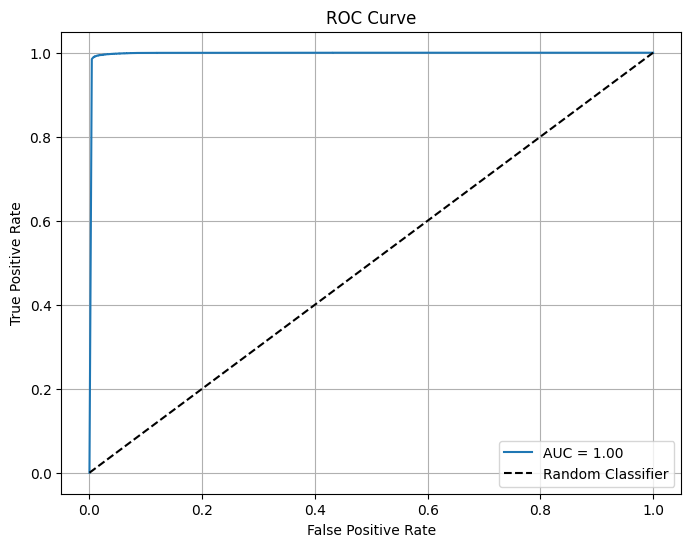

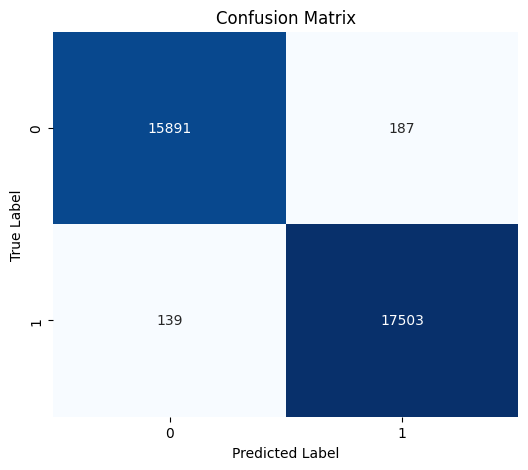

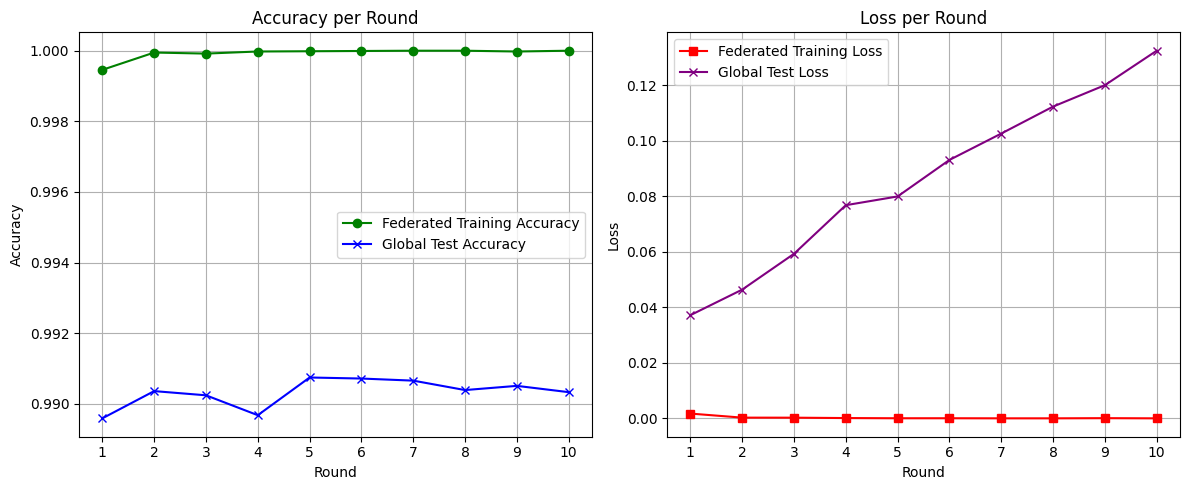

In [8]:

#diabetes_dataset with FL
# =========================================================
# KAGGLE-COMPATIBLE ONE-CELL CODE (UPDATED)
# diabetes + clinical_notes + TF-IDF + manual FedAvg
# with:
# - Federated Training Accuracy per round
# - Global Test Accuracy per round
# - Federated Training Loss per round
# - Global Test Loss per round
# - ROC AUC
# - Confusion Matrix
# - Final Accuracy / Precision / Recall / F1 / ROC AUC
# =========================================================

# Optional install if needed
# !pip install -q xgboost imbalanced-learn seaborn

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import TfidfVectorizer

# ============================
# 1. LOAD DATASET
# ============================
DATA_PATH = "/kaggle/input/datasets/aqsaaries/diabetese/diabetes_dataset.csv"  # <-- change if needed

if not os.path.exists(DATA_PATH):
    print("⚠️ DATA_PATH not found. Showing available files in /kaggle/input:\n")
    shown = 0
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
            shown += 1
            if shown >= 30:
                break
        if shown >= 30:
            break
    raise FileNotFoundError("Please update DATA_PATH to the correct Kaggle dataset path.")

data = pd.read_csv(DATA_PATH)
print("✅ Dataset loaded:", data.shape)

# ============================
# 2. HANDLE MISSING TARGET
# ============================
print("Missing values in target (diabetes):", data["diabetes"].isnull().sum())
data = data.dropna(subset=["diabetes"]).reset_index(drop=True)

# ============================
# 3. FEATURES / TARGET
# ============================
X = data.drop(columns=["diabetes"]).copy()
y = data["diabetes"].copy()

# ============================
# 4. ENCODE CATEGORICAL FEATURES
# ============================
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

if "clinical_notes" in X.columns:
    non_text_cats = [c for c in categorical_features if c != "clinical_notes"]
else:
    non_text_cats = categorical_features

for feature in non_text_cats:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature].astype(str))

# ============================
# 5. TF-IDF FOR clinical_notes
# ============================
if "clinical_notes" in X.columns:
    X["clinical_notes"] = X["clinical_notes"].astype(str).fillna("")
    tfidf_vectorizer = TfidfVectorizer(max_features=500)
    clinical_notes_tfidf = tfidf_vectorizer.fit_transform(X["clinical_notes"]).toarray()

    X_structured = X.drop(columns=["clinical_notes"]).values
    X = np.hstack((X_structured, clinical_notes_tfidf))
else:
    X = X.values

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y)

print("✅ Feature matrix shape before balancing:", X.shape)

# ============================
# 6. SMOTEENN BALANCING
# ============================
smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X, y)

print("✅ After SMOTEENN:", X_resampled.shape)
print("Class distribution after balancing:")
print(pd.Series(y_resampled).value_counts())

# ============================
# 7. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# ============================
# 8. STANDARDIZATION
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 9. HYPERPARAMETER TUNING
# ============================
def hyperparameter_tuning():
    print("\n⏳ Tuning RandomForest...")
    param_grid_rf = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10]
    }
    grid_rf = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_rf,
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_rf.fit(X_train_scaled, y_train)
    best_rf = grid_rf.best_estimator_
    print("✅ Best RF:", grid_rf.best_params_)

    print("\n⏳ Tuning XGBoost...")
    param_grid_xgb = {
        "learning_rate": [0.01, 0.1],
        "n_estimators": [100, 200]
    }
    grid_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric="logloss"),
        param_grid_xgb,
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_xgb.fit(X_train_scaled, y_train)
    best_xgb = grid_xgb.best_estimator_
    print("✅ Best XGB:", grid_xgb.best_params_)

    return best_rf, best_xgb

best_rf, best_xgb = hyperparameter_tuning()

# ============================
# 10. STACKING CLASSIFIER
# ============================
base_models = [
    ("Random Forest", best_rf),
    ("XGBoost", best_xgb),
    ("SVM", SVC(kernel="rbf", probability=True)),
    ("KNN", KNeighborsClassifier(n_neighbors=5))
]

meta_model = LogisticRegression(max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)
stacking_clf.fit(X_train_scaled, y_train)
print("\n✅ Stacking classifier trained")

# ============================
# 11. CREATE META FEATURES
# ============================
meta_train_list = []
meta_test_list = []

for name, model in base_models:
    model.fit(X_train_scaled, y_train)
    meta_train_list.append(model.predict_proba(X_train_scaled)[:, 1])
    meta_test_list.append(model.predict_proba(X_test_scaled)[:, 1])

meta_train = np.column_stack(meta_train_list)
meta_test = np.column_stack(meta_test_list)

X_train_combined = np.hstack((X_train_scaled, meta_train)).astype(np.float32)
X_test_combined = np.hstack((X_test_scaled, meta_test)).astype(np.float32)

y_train_array = np.array(y_train).astype(np.float32)
y_test_array = np.array(y_test).astype(np.float32)

print("✅ Combined train shape:", X_train_combined.shape)
print("✅ Combined test shape:", X_test_combined.shape)

# ============================
# 12. FEDERATED LEARNING SETUP
# ============================
NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 0.001

# Split into clients
X_parts = np.array_split(X_train_combined, NUM_CLIENTS)
y_parts = np.array_split(y_train_array, NUM_CLIENTS)

def create_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def average_weights(weight_list):
    avg_weights = []
    for weights in zip(*weight_list):
        avg_weights.append(np.mean(weights, axis=0))
    return avg_weights

input_dim = X_train_combined.shape[1]
global_model = create_model(input_dim)
global_weights = global_model.get_weights()

# History storage for exact same graphs
rounds_list = []
client_avg_losses = []
client_avg_accuracies = []
global_test_losses = []
global_test_accuracies = []

print("\n🚀 Starting Federated Training...\n")

# ============================
# 13. FEDERATED TRAINING LOOP
# ============================
for rnd in range(NUM_ROUNDS):
    local_weights = []
    local_losses = []
    local_accuracies = []

    for client_id in range(NUM_CLIENTS):
        client_model = create_model(input_dim)
        client_model.set_weights(global_weights)

        client_model.fit(
            X_parts[client_id],
            y_parts[client_id],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        c_loss, c_acc = client_model.evaluate(
            X_parts[client_id],
            y_parts[client_id],
            verbose=0
        )

        local_losses.append(c_loss)
        local_accuracies.append(c_acc)
        local_weights.append(client_model.get_weights())

    # FedAvg
    global_weights = average_weights(local_weights)
    global_model.set_weights(global_weights)

    # client-average metrics
    avg_client_loss = float(np.mean(local_losses))
    avg_client_acc = float(np.mean(local_accuracies))

    # global model test metrics
    g_loss, g_acc = global_model.evaluate(X_test_combined, y_test_array, verbose=0)

    rounds_list.append(rnd + 1)
    client_avg_losses.append(avg_client_loss)
    client_avg_accuracies.append(avg_client_acc)
    global_test_losses.append(float(g_loss))
    global_test_accuracies.append(float(g_acc))

    print(
        f"Round {rnd+1:02d}/{NUM_ROUNDS} | "
        f"Federated Training Accuracy: {avg_client_acc:.4f} | "
        f"Global Test Accuracy: {g_acc:.4f} | "
        f"Federated Training Loss: {avg_client_loss:.4f} | "
        f"Global Test Loss: {g_loss:.4f}"
    )

print("\n✅ Federated training completed")

# ============================
# 14. FINAL EVALUATION
# ============================
final_loss, final_acc = global_model.evaluate(X_test_combined, y_test_array, verbose=0)
print(f"\n🔍 Final Test Loss: {final_loss:.4f}")
print(f"🔍 Final Test Accuracy: {final_acc:.4f}")

y_pred_probs = global_model.predict(X_test_combined, verbose=0).flatten()
y_pred_labels = (y_pred_probs > 0.5).astype(int)

print("\n📄 Classification Report:\n")
print(classification_report(y_test_array, y_pred_labels))

final_accuracy = accuracy_score(y_test_array, y_pred_labels)
final_precision = precision_score(y_test_array, y_pred_labels)
final_recall = recall_score(y_test_array, y_pred_labels)
final_f1 = f1_score(y_test_array, y_pred_labels)
final_auc = roc_auc_score(y_test_array, y_pred_probs)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC AUC  : {final_auc:.4f}")

# ============================
# 15. ROC CURVE
# ============================
fpr, tpr, _ = roc_curve(y_test_array, y_pred_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {final_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ============================
# 16. CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test_array, y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ============================
# 17. EXACT SAME COMBINED 2 GRAPHS
# ============================
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(
    rounds_list,
    client_avg_accuracies,
    marker='o',
    color='green',
    label='Federated Training Accuracy'
)
plt.plot(
    rounds_list,
    global_test_accuracies,
    marker='x',
    color='blue',
    label='Global Test Accuracy'
)
plt.title("Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.xticks(rounds_list)
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(
    rounds_list,
    client_avg_losses,
    marker='s',
    color='red',
    label='Federated Training Loss'
)
plt.plot(
    rounds_list,
    global_test_losses,
    marker='x',
    color='purple',
    label='Global Test Loss'
)
plt.title("Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.xticks(rounds_list)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

✅ Feature shape after TF-IDF: (100000, 8)

⏳ Tuning RandomForest (Expanded)...
✅ Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

⏳ Tuning XGBoost (Expanded)...
✅ Best XGB Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}

🔁 3-Fold Cross-Validation Results:
Accuracy:  0.9889
Precision: 0.9908
Recall:    0.9879
F1 Score:  0.9894

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16078
           1       0.99      0.99      0.99     17642

    accuracy                           0.99     33720
   macro avg       0.99      0.99      0.99     33720
weighted avg       0.99      0.99      0.99     33720



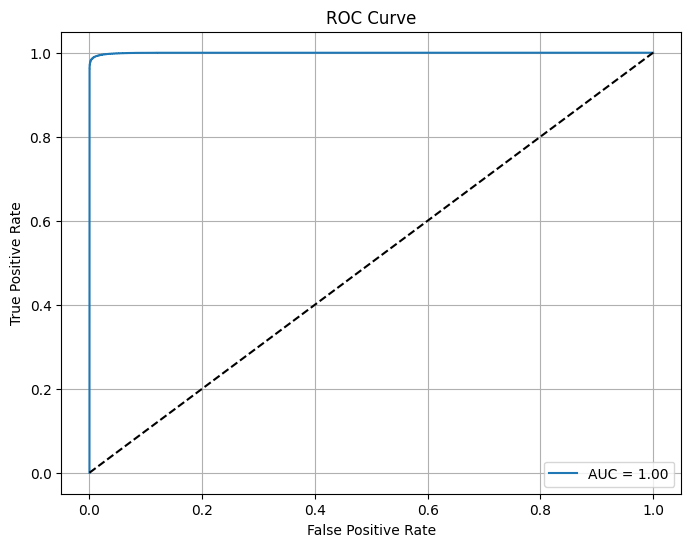

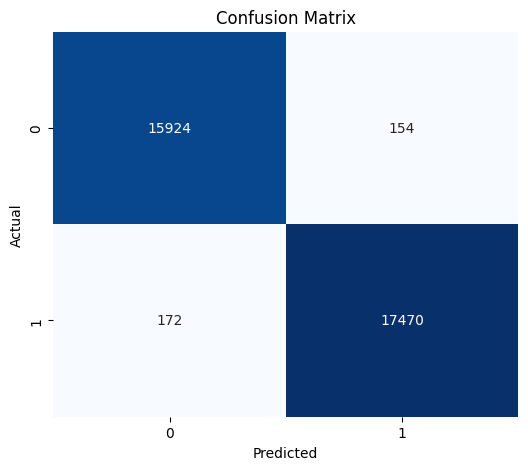

In [1]:
# =========================================================
# diabetes_dataset WITHOUT FL (FINAL - CV=3 MATCHED)
# =========================================================

from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score, confusion_matrix, make_scorer, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================
# 1. LOAD DATA
# ============================
data = pd.read_csv('/kaggle/input/datasets/aqsaaries/diabetese/diabetes_dataset.csv')

# ============================
# 2. SPLIT FEATURES / TARGET
# ============================
X = data.drop(columns=['diabetes']).copy()
y = data['diabetes'].copy()

# ============================
# 3. HANDLE CATEGORICAL FEATURES
# ============================
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

if "clinical_notes" in categorical_features:
    categorical_features.remove("clinical_notes")

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ============================
# 4. TF-IDF FOR clinical_notes
# ============================
if "clinical_notes" in X.columns:
    X["clinical_notes"] = X["clinical_notes"].astype(str).fillna("")
    tfidf = TfidfVectorizer(max_features=500)

    text_features = tfidf.fit_transform(X["clinical_notes"]).toarray()
    X_structured = X.drop(columns=["clinical_notes"]).values

    X = np.hstack((X_structured, text_features))
else:
    X = X.values

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y)

print("✅ Feature shape after TF-IDF:", X.shape)

# ============================
# 5. HANDLE IMBALANCE
# ============================
smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X, y)

# ============================
# 6. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# ============================
# 7. STANDARDIZATION
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================

# ============================
# 8. HYPERPARAMETER TUNING (ADVANCED - FL STYLE)
# ============================
def hyperparameter_tuning():

    print("\n⏳ Tuning RandomForest (Expanded)...")
    param_grid_rf = {
        'n_estimators': [100, 200, 300],   # expanded like FL-style search
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    grid_rf = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_rf,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    grid_rf.fit(X_train_scaled, y_train)
    best_rf = grid_rf.best_estimator_

    print("✅ Best RF Params:", grid_rf.best_params_)

    print("\n⏳ Tuning XGBoost (Expanded)...")
    param_grid_xgb = {
        'learning_rate': [0.01, 0.05, 0.1],   # expanded
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7]
    }

    grid_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid_xgb,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    grid_xgb.fit(X_train_scaled, y_train)
    best_xgb = grid_xgb.best_estimator_

    print("✅ Best XGB Params:", grid_xgb.best_params_)

    return best_rf, best_xgb

best_rf, best_xgb = hyperparameter_tuning()


# ============================
# 9. STACKING MODEL (CV=3)
# ============================
base_models = [
    ('Random Forest', best_rf),
    ('XGBoost', best_xgb),
    ('SVM', SVC(kernel='rbf', probability=True)),
    ('KNN', KNeighborsClassifier(n_neighbors=5))
]

meta_model = LogisticRegression(max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)

# ============================
# 10. CROSS VALIDATION (CV=3)
# ============================
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

cv_results = cross_validate(
    stacking_clf,
    X_train_scaled,
    y_train,
    cv=3,
    scoring=scoring
)

print("\n🔁 3-Fold Cross-Validation Results:")
print(f"Accuracy:  {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
print(f"Recall:    {np.mean(cv_results['test_recall']):.4f}")
print(f"F1 Score:  {np.mean(cv_results['test_f1']):.4f}")

# ============================
# 11. TRAIN FINAL MODEL
# ============================
stacking_clf.fit(X_train_scaled, y_train)

# ============================
# 12. TEST EVALUATION
# ============================
y_pred = stacking_clf.predict(X_test_scaled)
y_proba = stacking_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ============================
# 13. ROC CURVE
# ============================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# 14. CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



🔁 3-Fold Cross-Validation Results (Centralized):
Accuracy:  0.9861
Precision: 0.9909
Recall:    0.9833
F1 Score:  0.9871

📈 Test Results:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     15412
           1       0.99      0.98      0.99     18158

    accuracy                           0.99     33570
   macro avg       0.99      0.99      0.99     33570
weighted avg       0.99      0.99      0.99     33570



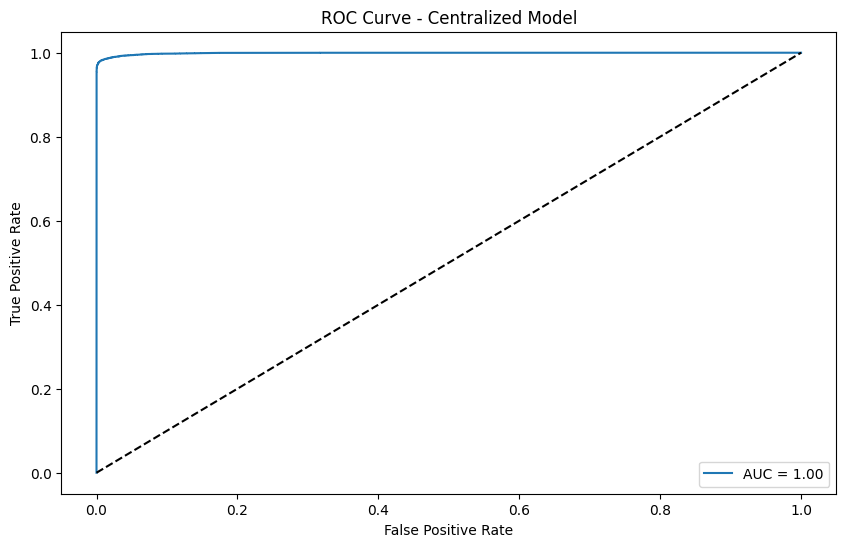

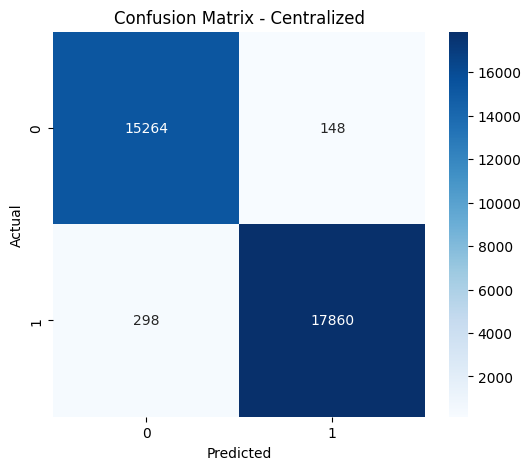

In [2]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix, make_scorer, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==============================
# 📌 Load Dataset
# ==============================
data = pd.read_csv('/kaggle/input/datasets/aqsaaries/diabetese-dataset-with-notesss/diabetes_dataset_with_notes.csv')
data = data.dropna(subset=['diabetes'])

# ==============================
# 🎯 Feature / Target
# ==============================
X = data.drop(columns=['diabetes'])
y = data['diabetes']

# ==============================
# 🏷️ Encoding
# ==============================
categorical_features = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_features:
    X[col] = le.fit_transform(X[col].astype(str))

# ==============================
# 📌 TF-IDF (same as FL)
# ==============================
if 'clinical_notes' in X.columns:
    X['clinical_notes'] = X['clinical_notes'].astype(str)
    tfidf = TfidfVectorizer(max_features=500)
    tfidf_features = tfidf.fit_transform(X['clinical_notes']).toarray()
    
    X = X.drop(columns=['clinical_notes'])
    X = np.hstack((X.values, tfidf_features))
else:
    X = X.values

# ==============================
# ⚖️ Balance Data (SMOTEENN)
# ==============================
smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X, y)

# ==============================
# 🔀 Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# ==============================
# ⚖️ Scaling
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 🔍 Hyperparameter Tuning (UPDATED)
# ==============================
def hyperparameter_tuning():
    # Random Forest
    param_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10]
    }

    rf = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_rf,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    rf.fit(X_train_scaled, y_train)

    # XGBoost
    param_xgb = {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200]
    }

    xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss'),
        param_xgb,
        cv=3,
        n_jobs=-1,
        scoring='accuracy'
    )
    xgb.fit(X_train_scaled, y_train)

    return rf.best_estimator_, xgb.best_estimator_

# Get best models
best_rf, best_xgb = hyperparameter_tuning()

# ==============================
# 🔗 Base Models
# ==============================
base_models = [
    ('Random Forest', best_rf),
    ('XGBoost', best_xgb),
    ('KNN', KNeighborsClassifier(n_neighbors=5))
]

# ==============================
# ➕ Meta Model
# ==============================
meta_model = LogisticRegression()

# ==============================
# 🔁 Stacking Model
# ==============================
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)

# ==============================
# 🔬 Cross Validation (same as FL)
# ==============================
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

cv_results = cross_validate(
    stacking_clf,
    X_train_scaled,
    y_train,
    cv=3,
    scoring=scoring
)

print("\n🔁 3-Fold Cross-Validation Results (Centralized):")
print(f"Accuracy:  {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
print(f"Recall:    {np.mean(cv_results['test_recall']):.4f}")
print(f"F1 Score:  {np.mean(cv_results['test_f1']):.4f}")

# ==============================
# 🚀 Train Final Model
# ==============================
stacking_clf.fit(X_train_scaled, y_train)

# ==============================
# 🔮 Prediction
# ==============================
y_pred = stacking_clf.predict(X_test_scaled)
y_proba = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# ==============================
# 📋 Classification Report
# ==============================
print("\n📈 Test Results:\n")
print(classification_report(y_test, y_pred))

# ==============================
# 📉 ROC Curve
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Centralized Model')
plt.legend()
plt.show()

# ==============================
# 📊 Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Centralized')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Checkpoint folder: /kaggle/working/fed_resume_ckpt
✅ Dataset loaded: (100000, 17)
⏳ Running preprocessing from scratch...
Feature matrix shape before balancing: (100000, 81)
✅ After SMOTEENN: (168024, 81)
Class distribution after balancing:
1    90438
0    77586
Name: count, dtype: int64
✅ Preprocessed data saved
Train shape: (134419, 81)
Test shape : (33605, 81)
⏳ Tuning RandomForest...
✅ Best RF: {'max_depth': None, 'n_estimators': 200}
⏳ Tuning XGBoost...
✅ Best XGB: {'learning_rate': 0.1, 'n_estimators': 200}
✅ Tuned models saved
✅ Combined train shape: (134419, 85)
✅ Combined test shape: (33605, 85)
✅ Starting federated training from round 1
Round 01/10 | Federated Training Accuracy: 0.9959 | Federated Training Loss: 0.0115 | Global Test Accuracy: 0.9825 | Global Test Loss: 0.0623
Round 02/10 | Federated Training Accuracy: 0.9971 | Federated Training Loss: 0.0113 | Global Test Accuracy: 0.9835 | Global Test Loss: 0.0678
Round 03/10 | Federated Training Accuracy: 0.9991 | Federated

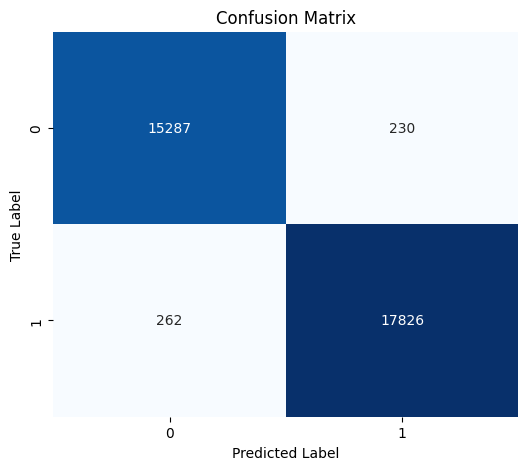

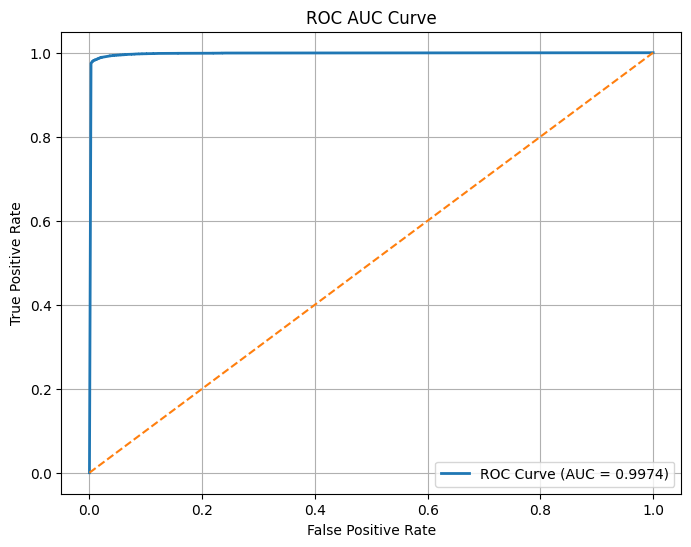

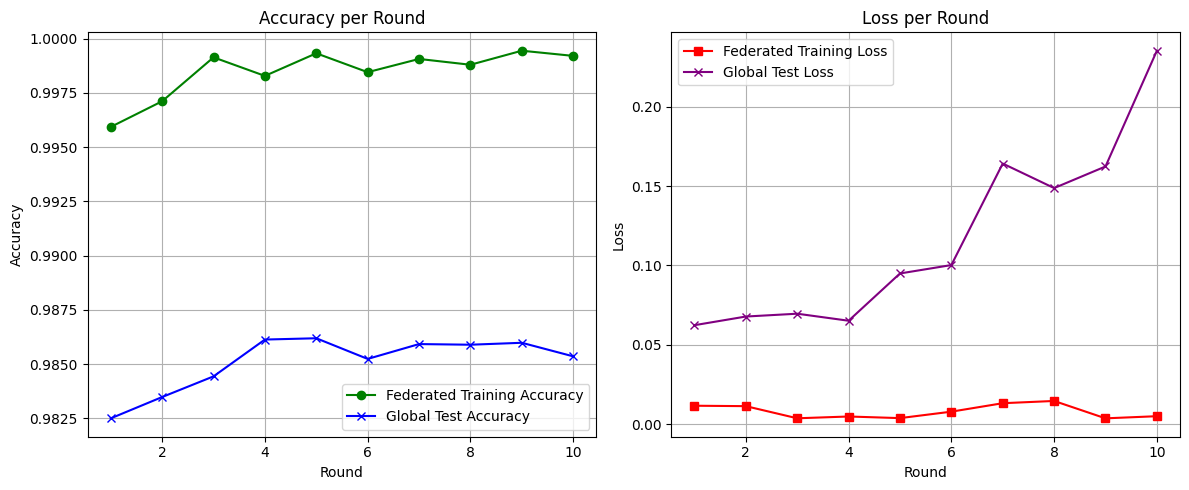


✅ Complete code finished successfully.
✅ Only requested graphs are included.
✅ If session disconnects, re-run the same code: it will resume from saved checkpoint.


In [9]:
#diabetes_dataset_with_notes with FL
# =========================================================
# COMPLETE KAGGLE CODE WITH CHECKPOINT + RESUME
# DIABETES + CLINICAL_NOTES + TF-IDF + STACKING + MANUAL FEDAVG
# ONLY:
# - Confusion Matrix
# - ROC AUC Curve
# - Accuracy per Round
# - Loss per Round
# - Final Accuracy / Precision / Recall / F1 / ROC AUC
# =========================================================

# Optional installs
# !pip install -q xgboost imbalanced-learn seaborn joblib

import os
import json
import pickle
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report, accuracy_score, roc_curve, roc_auc_score,
    confusion_matrix, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================================================
# 0. CONFIG
# =========================================================
DATA_PATH = "/kaggle/input/datasets/aqsaaries/diabetese-dataset-with-notesss/diabetes_dataset_with_notes.csv"  # <-- CHANGE IF NEEDED

TARGET_COL = "diabetes"
TEXT_COL = "clinical_notes"

NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 0.01
RANDOM_STATE = 42

# Checkpoint folder
CHECKPOINT_DIR = "/kaggle/working/fed_resume_ckpt"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

PREPROCESS_FILE = os.path.join(CHECKPOINT_DIR, "preprocessed_data.npz")
MODELS_FILE = os.path.join(CHECKPOINT_DIR, "trained_models.pkl")
ROUND_STATE_FILE = os.path.join(CHECKPOINT_DIR, "round_state.json")
WEIGHTS_FILE = os.path.join(CHECKPOINT_DIR, "global_weights.pkl")
FINAL_RESULTS_FILE = os.path.join(CHECKPOINT_DIR, "final_results.pkl")

print("Checkpoint folder:", CHECKPOINT_DIR)

# =========================================================
# 1. LOAD RAW DATA
# =========================================================
if not os.path.exists(DATA_PATH):
    print("⚠️ DATA_PATH not found. Showing available files under /kaggle/input:\n")
    shown = 0
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
            shown += 1
            if shown >= 50:
                break
        if shown >= 50:
            break
    raise FileNotFoundError("Please update DATA_PATH to the correct Kaggle dataset path.")

data = pd.read_csv(DATA_PATH)
print("✅ Dataset loaded:", data.shape)

if TARGET_COL not in data.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available columns: {list(data.columns)}")

# =========================================================
# 2. PREPROCESS OR LOAD PREPROCESSED
# =========================================================
if os.path.exists(PREPROCESS_FILE):
    print("✅ Loading saved preprocessed data...")

    saved = np.load(PREPROCESS_FILE, allow_pickle=True)
    X_train_scaled = saved["X_train_scaled"]
    X_test_scaled = saved["X_test_scaled"]
    y_train = saved["y_train"]
    y_test = saved["y_test"]

else:
    print("⏳ Running preprocessing from scratch...")

    # Drop missing target
    data = data.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    X_df = data.drop(columns=[TARGET_COL]).copy()
    y = data[TARGET_COL].copy()

    # Encode categorical features except clinical_notes
    categorical_features = X_df.select_dtypes(include=["object"]).columns.tolist()
    use_text = TEXT_COL in X_df.columns

    for col in categorical_features:
        if col != TEXT_COL:
            le = LabelEncoder()
            X_df[col] = le.fit_transform(X_df[col].astype(str))

    # TF-IDF on clinical_notes
    if use_text:
        X_df[TEXT_COL] = X_df[TEXT_COL].astype(str).fillna("")
        tfidf_vectorizer = TfidfVectorizer(max_features=500)
        clinical_notes_tfidf = tfidf_vectorizer.fit_transform(X_df[TEXT_COL]).toarray()
        structured_df = X_df.drop(columns=[TEXT_COL]).copy()
        X = np.hstack((structured_df.values, clinical_notes_tfidf))
    else:
        X = X_df.values

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)

    print("Feature matrix shape before balancing:", X.shape)

    # SMOTEENN
    smoteenn = SMOTEENN(random_state=RANDOM_STATE)
    X_resampled, y_resampled = smoteenn.fit_resample(X, y)

    print("✅ After SMOTEENN:", X_resampled.shape)
    print("Class distribution after balancing:")
    print(pd.Series(y_resampled).value_counts())

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled,
        y_resampled,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_resampled
    )

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_test_scaled = scaler.transform(X_test).astype(np.float32)

    # Save preprocessing
    np.savez(
        PREPROCESS_FILE,
        X_train_scaled=X_train_scaled,
        X_test_scaled=X_test_scaled,
        y_train=np.array(y_train),
        y_test=np.array(y_test)
    )

    print("✅ Preprocessed data saved")

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

# =========================================================
# 3. TUNE / LOAD MODELS
# =========================================================
if os.path.exists(MODELS_FILE):
    print("✅ Loading tuned models...")
    saved_models = joblib.load(MODELS_FILE)
    best_rf = saved_models["best_rf"]
    best_xgb = saved_models["best_xgb"]
    stacking_clf = saved_models["stacking_clf"]
else:
    print("⏳ Tuning RandomForest...")
    grid_rf = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10]
        },
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_rf.fit(X_train_scaled, y_train)
    best_rf = grid_rf.best_estimator_
    print("✅ Best RF:", grid_rf.best_params_)

    print("⏳ Tuning XGBoost...")
    grid_xgb = GridSearchCV(
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),
        {
            "learning_rate": [0.01, 0.1],
            "n_estimators": [100, 200]
        },
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_xgb.fit(X_train_scaled, y_train)
    best_xgb = grid_xgb.best_estimator_
    print("✅ Best XGB:", grid_xgb.best_params_)

    base_models_for_stack = [
        ("Random Forest", best_rf),
        ("XGBoost", best_xgb),
        ("SVM", SVC(kernel="rbf", probability=True)),
        ("KNN", KNeighborsClassifier(n_neighbors=5))
    ]

    stacking_clf = StackingClassifier(
        estimators=base_models_for_stack,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=3,
        n_jobs=-1
    )
    stacking_clf.fit(X_train_scaled, y_train)

    joblib.dump({
        "best_rf": best_rf,
        "best_xgb": best_xgb,
        "stacking_clf": stacking_clf
    }, MODELS_FILE)

    print("✅ Tuned models saved")

# =========================================================
# 4. CREATE META FEATURES FOR FEDERATED MODEL
# =========================================================
meta_train_list = []
meta_test_list = []

base_models = [
    ("Random Forest", best_rf),
    ("XGBoost", best_xgb),
    ("SVM", SVC(kernel="rbf", probability=True)),
    ("KNN", KNeighborsClassifier(n_neighbors=5))
]

for name, model in base_models:
    model.fit(X_train_scaled, y_train)
    meta_train_list.append(model.predict_proba(X_train_scaled)[:, 1])
    meta_test_list.append(model.predict_proba(X_test_scaled)[:, 1])

meta_train = np.column_stack(meta_train_list)
meta_test = np.column_stack(meta_test_list)

X_train_combined = np.hstack((X_train_scaled, meta_train)).astype(np.float32)
X_test_combined = np.hstack((X_test_scaled, meta_test)).astype(np.float32)

y_train_array = np.array(y_train).astype(np.float32)
y_test_array = np.array(y_test).astype(np.float32)

print("✅ Combined train shape:", X_train_combined.shape)
print("✅ Combined test shape:", X_test_combined.shape)

# =========================================================
# 5. FEDERATED SETUP
# =========================================================
X_train_fed = X_train_combined
X_test_fed = X_test_combined
y_train_fed = y_train_array
y_test_fed = y_test_array

# Split into clients
data_per_client = len(X_train_fed) // NUM_CLIENTS
X_parts, y_parts = [], []

for i in range(NUM_CLIENTS):
    start_idx = i * data_per_client
    end_idx = (i + 1) * data_per_client if i != NUM_CLIENTS - 1 else len(X_train_fed)
    X_parts.append(X_train_fed[start_idx:end_idx])
    y_parts.append(y_train_fed[start_idx:end_idx])

def create_federated_model(input_dim):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def average_weights(weight_list):
    avg_weights = []
    for weights in zip(*weight_list):
        avg_weights.append(np.mean(weights, axis=0))
    return avg_weights

def save_round_state(round_num, global_weights, round_accuracy, round_loss, global_test_accuracy, global_test_loss):
    with open(WEIGHTS_FILE, "wb") as f:
        pickle.dump(global_weights, f)

    state = {
        "last_completed_round": round_num,
        "round_accuracy": round_accuracy,
        "round_loss": round_loss,
        "global_test_accuracy": global_test_accuracy,
        "global_test_loss": global_test_loss
    }
    with open(ROUND_STATE_FILE, "w") as f:
        json.dump(state, f)

def load_round_state():
    if os.path.exists(ROUND_STATE_FILE) and os.path.exists(WEIGHTS_FILE):
        with open(ROUND_STATE_FILE, "r") as f:
            state = json.load(f)
        with open(WEIGHTS_FILE, "rb") as f:
            global_weights = pickle.load(f)

        return (
            state["last_completed_round"],
            global_weights,
            state["round_accuracy"],
            state["round_loss"],
            state["global_test_accuracy"],
            state["global_test_loss"]
        )
    return None

# =========================================================
# 6. RESUME-ENABLED FEDERATED TRAINING
# =========================================================
input_dim = X_train_fed.shape[1]
global_model = create_federated_model(input_dim)

loaded_state = load_round_state()

if loaded_state is not None:
    (
        last_completed_round,
        global_weights,
        round_accuracy,
        round_loss,
        global_test_accuracy,
        global_test_loss
    ) = loaded_state

    start_round = last_completed_round + 1
    global_model.set_weights(global_weights)
    print(f"✅ Resuming federated training from round {start_round + 1}")
else:
    global_weights = global_model.get_weights()
    round_accuracy = []
    round_loss = []
    global_test_accuracy = []
    global_test_loss = []
    start_round = 0
    print("✅ Starting federated training from round 1")

for round_num in range(start_round, NUM_ROUNDS):
    local_weights = []
    local_accuracies = []
    local_losses = []

    for client_id in range(NUM_CLIENTS):
        client_model = create_federated_model(input_dim)
        client_model.set_weights(global_weights)

        client_model.fit(
            X_parts[client_id],
            y_parts[client_id],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        loss, acc = client_model.evaluate(
            X_parts[client_id],
            y_parts[client_id],
            verbose=0
        )

        local_losses.append(loss)
        local_accuracies.append(acc)
        local_weights.append(client_model.get_weights())

    global_weights = average_weights(local_weights)
    global_model.set_weights(global_weights)

    avg_acc = float(np.mean(local_accuracies))
    avg_loss = float(np.mean(local_losses))

    g_loss, g_acc = global_model.evaluate(X_test_fed, y_test_fed, verbose=0)

    round_accuracy.append(avg_acc)
    round_loss.append(avg_loss)
    global_test_accuracy.append(float(g_acc))
    global_test_loss.append(float(g_loss))

    print(
        f"Round {round_num+1:02d}/{NUM_ROUNDS} | "
        f"Federated Training Accuracy: {avg_acc:.4f} | "
        f"Federated Training Loss: {avg_loss:.4f} | "
        f"Global Test Accuracy: {g_acc:.4f} | "
        f"Global Test Loss: {g_loss:.4f}"
    )

    save_round_state(
        round_num,
        global_weights,
        round_accuracy,
        round_loss,
        global_test_accuracy,
        global_test_loss
    )

print("\n✅ Federated training completed")

# =========================================================
# 7. FINAL EVALUATION
# =========================================================
final_model = create_federated_model(input_dim)
final_model.set_weights(global_weights)

final_loss, final_accuracy = final_model.evaluate(X_test_fed, y_test_fed, verbose=0)

y_pred_proba = final_model.predict(X_test_fed, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ Final Federated Model Test Accuracy: {final_accuracy:.4f}")
print(f"✅ Final Federated Model Test Loss: {final_loss:.4f}")
print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred))
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

with open(FINAL_RESULTS_FILE, "wb") as f:
    pickle.dump({
        "final_accuracy": final_accuracy,
        "final_loss": final_loss,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba
    }, f)

# =========================================================
# 8. ONLY REQUIRED PLOTS
# =========================================================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Accuracy & Loss per Round
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(round_accuracy)+1), round_accuracy, marker="o", color="green", label="Federated Training Accuracy")
plt.plot(range(1, len(global_test_accuracy)+1), global_test_accuracy, marker="x", color="blue", label="Global Test Accuracy")
plt.title("Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(round_loss)+1), round_loss, marker="s", color="red", label="Federated Training Loss")
plt.plot(range(1, len(global_test_loss)+1), global_test_loss, marker="x", color="purple", label="Global Test Loss")
plt.title("Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Complete code finished successfully.")
print("✅ Only requested graphs are included.")
print("✅ If session disconnects, re-run the same code: it will resume from saved checkpoint.")

**Rough work**

In [ ]:
# =========================================================
# LEAKAGE-FREE KAGGLE-COMPATIBLE ONE-CELL CODE
# diabetes + clinical_notes + TF-IDF + OOF stacking + manual FedAvg
# =========================================================

# Optional install if needed
# !pip install -q xgboost imbalanced-learn seaborn

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.combine import SMOTEENN

# =========================================================
# 1. CONFIG
# =========================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "/kaggle/input/datasets/aqsaaries/diabetese/diabetes_dataset.csv"  # change if needed

NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 0.001

# =========================================================
# 2. LOAD DATASET
# =========================================================
if not os.path.exists(DATA_PATH):
    print("⚠️ DATA_PATH not found. Showing available files in /kaggle/input:\n")
    shown = 0
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
            shown += 1
            if shown >= 30:
                break
        if shown >= 30:
            break
    raise FileNotFoundError("Please update DATA_PATH to the correct Kaggle dataset path.")

data = pd.read_csv(DATA_PATH)
print("✅ Dataset loaded:", data.shape)

# =========================================================
# 3. HANDLE TARGET + BASIC CLEANING
# =========================================================
if "diabetes" not in data.columns:
    raise ValueError("Target column 'diabetes' not found in dataset.")

print("Missing values in target (diabetes):", data["diabetes"].isnull().sum())
data = data.dropna(subset=["diabetes"]).reset_index(drop=True)

# Separate X and y
X_df = data.drop(columns=["diabetes"]).copy()
y = data["diabetes"].copy()

# Ensure binary numeric target
if y.dtype == "object":
    y = y.astype(str).str.strip().str.lower().map({
        "0": 0, "1": 1,
        "no": 0, "yes": 1,
        "false": 0, "true": 1,
        "negative": 0, "positive": 1
    })
if y.isnull().any():
    raise ValueError("Target column contains unsupported labels. Please inspect 'diabetes' values.")

y = y.astype(int)

print("\nOriginal class distribution:")
print(y.value_counts())

# =========================================================
# 4. TRAIN / TEST SPLIT FIRST  ✅ NO LEAKAGE
# =========================================================
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_df = X_train_df.reset_index(drop=True)
X_test_df = X_test_df.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("\n✅ Train shape:", X_train_df.shape)
print("✅ Test shape :", X_test_df.shape)

# =========================================================
# 5. PREPROCESSING WITHOUT LEAKAGE
#    - categorical encoding fit on TRAIN only
#    - TF-IDF fit on TRAIN only
# =========================================================
def preprocess_train_test(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Detect text column
    text_col = "clinical_notes" if "clinical_notes" in train_df.columns else None

    # Separate categorical non-text columns
    categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
    if text_col in categorical_cols:
        categorical_cols.remove(text_col)

    # Encode non-text categorical columns using TRAIN mappings only
    for col in categorical_cols:
        train_df[col] = train_df[col].astype(str).fillna("missing")
        test_df[col] = test_df[col].astype(str).fillna("missing")

        unique_train_vals = train_df[col].unique().tolist()
        mapping = {val: idx for idx, val in enumerate(unique_train_vals)}

        train_df[col] = train_df[col].map(mapping).astype(np.int32)
        test_df[col] = test_df[col].map(mapping).fillna(-1).astype(np.int32)

    # Numeric missing handling
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        med = train_df[col].median()
        train_df[col] = train_df[col].fillna(med)
        test_df[col] = test_df[col].fillna(med)

    # TF-IDF for clinical_notes using TRAIN only
    if text_col is not None:
        train_text = train_df[text_col].astype(str).fillna("")
        test_text = test_df[text_col].astype(str).fillna("")

        tfidf = TfidfVectorizer(max_features=500)
        X_train_text = tfidf.fit_transform(train_text).toarray()
        X_test_text = tfidf.transform(test_text).toarray()

        train_structured = train_df.drop(columns=[text_col]).values
        test_structured = test_df.drop(columns=[text_col]).values

        X_train_final = np.hstack([train_structured, X_train_text])
        X_test_final = np.hstack([test_structured, X_test_text])

    else:
        X_train_final = train_df.values
        X_test_final = test_df.values

    return X_train_final.astype(np.float32), X_test_final.astype(np.float32)

X_train_raw, X_test_raw = preprocess_train_test(X_train_df, X_test_df)

print("\n✅ Feature matrix before balancing:")
print("Train:", X_train_raw.shape)
print("Test :", X_test_raw.shape)

# =========================================================
# 6. APPLY SMOTEENN ONLY ON TRAIN ✅ NO LEAKAGE
# =========================================================
smoteenn = SMOTEENN(random_state=SEED)
X_train_bal, y_train_bal = smoteenn.fit_resample(X_train_raw, y_train)

print("\n✅ After SMOTEENN (train only):", X_train_bal.shape)
print("Balanced train class distribution:")
print(pd.Series(y_train_bal).value_counts())

# =========================================================
# 7. STANDARDIZATION FIT ON TRAIN ONLY ✅ NO LEAKAGE
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_raw)

print("\n✅ Scaled train shape:", X_train_scaled.shape)
print("✅ Scaled test shape :", X_test_scaled.shape)

# =========================================================
# 8. HYPERPARAMETER TUNING ON TRAIN ONLY
# =========================================================
def hyperparameter_tuning(X_train, y_train):
    print("\n⏳ Tuning RandomForest...")
    param_grid_rf = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10]
    }
    grid_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=SEED),
        param_grid=param_grid_rf,
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    print("✅ Best RF:", grid_rf.best_params_)

    print("\n⏳ Tuning XGBoost...")
    param_grid_xgb = {
        "learning_rate": [0.01, 0.1],
        "n_estimators": [100, 200]
    }
    grid_xgb = GridSearchCV(
        estimator=XGBClassifier(
            random_state=SEED,
            eval_metric="logloss",
            use_label_encoder=False
        ),
        param_grid=param_grid_xgb,
        cv=3,
        n_jobs=-1,
        scoring="accuracy"
    )
    grid_xgb.fit(X_train, y_train)
    best_xgb = grid_xgb.best_estimator_
    print("✅ Best XGB:", grid_xgb.best_params_)

    return best_rf, best_xgb

best_rf, best_xgb = hyperparameter_tuning(X_train_scaled, y_train_bal)

# =========================================================
# 9. DEFINE BASE MODELS
# =========================================================
base_models = [
    ("rf", best_rf),
    ("xgb", best_xgb),
    ("svm", SVC(kernel="rbf", probability=True, random_state=SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
]

# =========================================================
# 10. OOF META-FEATURES (LEAKAGE-FREE STACKING)
# =========================================================
def generate_oof_meta_features(base_models, X_train, y_train, X_test, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    meta_train = np.zeros((X_train.shape[0], len(base_models)), dtype=np.float32)
    meta_test = np.zeros((X_test.shape[0], len(base_models)), dtype=np.float32)

    print("\n🚀 Generating leakage-free meta-features using OOF predictions...")

    for model_idx, (name, model) in enumerate(base_models):
        print(f"Training base model: {name}")

        test_fold_preds = np.zeros((X_test.shape[0], n_splits), dtype=np.float32)

        for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]

            mdl = clone(model)
            mdl.fit(X_tr, y_tr)

            meta_train[val_idx, model_idx] = mdl.predict_proba(X_val)[:, 1]
            test_fold_preds[:, fold_idx] = mdl.predict_proba(X_test)[:, 1]

        meta_test[:, model_idx] = test_fold_preds.mean(axis=1)

    return meta_train, meta_test

meta_train, meta_test = generate_oof_meta_features(
    base_models, X_train_scaled, np.array(y_train_bal), X_test_scaled, n_splits=5
)

print("✅ Meta-train shape:", meta_train.shape)
print("✅ Meta-test shape :", meta_test.shape)

# Combine original scaled features + meta-features
X_train_combined = np.hstack([X_train_scaled, meta_train]).astype(np.float32)
X_test_combined = np.hstack([X_test_scaled, meta_test]).astype(np.float32)

y_train_array = np.array(y_train_bal).astype(np.float32)
y_test_array = np.array(y_test).astype(np.float32)

print("\n✅ Combined train shape:", X_train_combined.shape)
print("✅ Combined test shape :", X_test_combined.shape)

# =========================================================
# 11. META MODEL (OPTIONAL CENTRALIZED CHECK)
# =========================================================
print("\n🚀 Pre-training meta model...")
meta_model = LogisticRegression(max_iter=1000, random_state=SEED)
meta_model.fit(meta_train, y_train_bal)

meta_test_pred = meta_model.predict(meta_test)
meta_test_prob = meta_model.predict_proba(meta_test)[:, 1]

print("\n================ CENTRALIZED STACKING CHECK ================")
print(classification_report(y_test, meta_test_pred))
print("Accuracy:", round(accuracy_score(y_test, meta_test_pred), 4))
print("Precision:", round(precision_score(y_test, meta_test_pred), 4))
print("Recall:", round(recall_score(y_test, meta_test_pred), 4))
print("F1 Score:", round(f1_score(y_test, meta_test_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, meta_test_prob), 4))

# =========================================================
# 12. FEDERATED MODEL SETUP
# =========================================================
def create_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def average_weights(weight_list):
    avg_weights = []
    for weights in zip(*weight_list):
        avg_weights.append(np.mean(weights, axis=0))
    return avg_weights

# Shuffle train before client split
perm = np.random.permutation(len(X_train_combined))
X_train_combined = X_train_combined[perm]
y_train_array = y_train_array[perm]

# Split into clients
X_parts = np.array_split(X_train_combined, NUM_CLIENTS)
y_parts = np.array_split(y_train_array, NUM_CLIENTS)

input_dim = X_train_combined.shape[1]
global_model = create_model(input_dim)
global_weights = global_model.get_weights()

# History
rounds_list = []
client_avg_losses = []
client_avg_accuracies = []
global_test_losses = []
global_test_accuracies = []

print("\n🚀 Starting Federated Training...\n")

# =========================================================
# 13. FEDERATED TRAINING LOOP
# =========================================================
for rnd in range(NUM_ROUNDS):
    local_weights = []
    local_losses = []
    local_accuracies = []

    for client_id in range(NUM_CLIENTS):
        client_model = create_model(input_dim)
        client_model.set_weights(global_weights)

        client_model.fit(
            X_parts[client_id],
            y_parts[client_id],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        c_loss, c_acc = client_model.evaluate(
            X_parts[client_id],
            y_parts[client_id],
            verbose=0
        )

        local_losses.append(c_loss)
        local_accuracies.append(c_acc)
        local_weights.append(client_model.get_weights())

    # FedAvg aggregation
    global_weights = average_weights(local_weights)
    global_model.set_weights(global_weights)

    # Round metrics
    avg_client_loss = float(np.mean(local_losses))
    avg_client_acc = float(np.mean(local_accuracies))
    g_loss, g_acc = global_model.evaluate(X_test_combined, y_test_array, verbose=0)

    rounds_list.append(rnd + 1)
    client_avg_losses.append(avg_client_loss)
    client_avg_accuracies.append(avg_client_acc)
    global_test_losses.append(float(g_loss))
    global_test_accuracies.append(float(g_acc))

    print(
        f"Round {rnd+1:02d}/{NUM_ROUNDS} | "
        f"Federated Training Accuracy: {avg_client_acc:.4f} | "
        f"Global Test Accuracy: {g_acc:.4f} | "
        f"Federated Training Loss: {avg_client_loss:.4f} | "
        f"Global Test Loss: {g_loss:.4f}"
    )

print("\n✅ Federated training completed")

# =========================================================
# 14. FINAL EVALUATION
# =========================================================
final_loss, final_acc = global_model.evaluate(X_test_combined, y_test_array, verbose=0)
print(f"\n🔍 Final Test Loss: {final_loss:.4f}")
print(f"🔍 Final Test Accuracy: {final_acc:.4f}")

y_pred_probs = global_model.predict(X_test_combined, verbose=0).flatten()
y_pred_labels = (y_pred_probs > 0.5).astype(int)

print("\n📄 Classification Report:\n")
print(classification_report(y_test_array, y_pred_labels))

final_accuracy = accuracy_score(y_test_array, y_pred_labels)
final_precision = precision_score(y_test_array, y_pred_labels)
final_recall = recall_score(y_test_array, y_pred_labels)
final_f1 = f1_score(y_test_array, y_pred_labels)
final_auc = roc_auc_score(y_test_array, y_pred_probs)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC AUC  : {final_auc:.4f}")

# =========================================================
# 15. ROC CURVE
# =========================================================
fpr, tpr, _ = roc_curve(y_test_array, y_pred_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {final_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test_array, y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================================
# 17. FEDERATED ACCURACY / LOSS PER ROUND
# =========================================================
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rounds_list, client_avg_accuracies, marker='o', color='green', label='Federated Training Accuracy')
plt.plot(rounds_list, global_test_accuracies, marker='x', color='blue', label='Global Test Accuracy')
plt.title("Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.xticks(rounds_list)
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rounds_list, client_avg_losses, marker='s', color='red', label='Federated Training Loss')
plt.plot(rounds_list, global_test_losses, marker='x', color='purple', label='Global Test Loss')
plt.title("Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.xticks(rounds_list)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()